<a href="https://colab.research.google.com/github/MiyoBran/Alura-ONE-G9/blob/main/formacion-estadisticas-y-machine-learning-grupo9-one/06-clasificacion-validacion-modelos-metricas-evaluacion/EST_06_Clasificacion_validacion_y_metricas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color='dark'>**Clasificación: Validación de modelos y métricas de evaluación**</h1>

### Proyecto

Una empresa de financiamiento de automóviles está atravesando una situación complicada, con una alta demanda para una flota reducida de vehículos y un alto número de morosos, lo que está generando grandes pérdidas para la empresa.

Nosotros fuimos contratados para buscar mejoras en la identificación de morosos. El análisis de los clientes actualmente se realiza de forma manual, cliente por cliente, lo que consume mucho tiempo y, aun así, la detección de morosos es muy imprecisa.

Nuestra tarea es utilizar los datos proporcionados por la empresa para **clasificar** a los clientes en cumplidores y morosos.

- [Base de datos-Original](https://github.com/alura-es-cursos/2162-clasificacion-validacion-de-modelos-y-metricas/blob/main/prestacar.csv)

## <font color='dark'>Clasificando los datos</h1>

### Creando un modelo inicial

In [1]:
import pandas as pd

In [2]:
# datos = pd.read_csv('/content/prestacar.csv')
url_original = 'https://github.com/MiyoBran/Alura-ONE-G9/blob/main/formacion-estadisticas-y-machine-learning-grupo9-one/06-clasificacion-validacion-modelos-metricas-evaluacion/prestacar.csv'
url = url_original.replace('/blob','').replace('github.com','raw.githubusercontent.com')
datos = pd.read_csv(url)

In [3]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54025 entries, 0 to 54024
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ingresos_cliente    54025 non-null  float64
 1   anualidad_prestamo  54025 non-null  float64
 2   años_casa_propia    54025 non-null  float64
 3   telefono_trab       54025 non-null  int64  
 4   evaluacion_ciudad   54025 non-null  float64
 5   score_1             54025 non-null  float64
 6   score_2             54025 non-null  float64
 7   score_3             54025 non-null  float64
 8   score_social        54025 non-null  float64
 9   cambio_telefono     54025 non-null  float64
 10  moroso              54025 non-null  int64  
dtypes: float64(9), int64(2)
memory usage: 4.5 MB


In [4]:
#Creamos un modelo inicial
X = datos.drop(columns='moroso',axis=1)
y = datos.moroso

In [5]:
#Usaremos DecisiontreeClassifier
from sklearn.tree import DecisionTreeClassifier

modelo = DecisionTreeClassifier()
modelo.fit(X,y)
modelo.score(X,y)

1.0

In [6]:
print(f'La exactitud del modelo es: {modelo.score(X,y)}')

La exactitud del modelo es: 1.0


### Validando el modelo

Evaluar el modelo con los mismos datos utilizados en el entrenamiento no es recomendable. Es necesario que la evaluación se realice con datos independientes.  

Evaluar el modelo con los propios datos de entrenamiento sería equivalente a entregar un examen con las preguntas y las respuestas a una persona y, al momento de evaluarla nuevamente, entregarle un examen con las mismas preguntas y opciones. Se espera que esa persona obtenga un buen resultado, ya que ya ha visto las respuestas y ha memorizado el resultado. Esto es diferente de haber aprendido la materia a partir de ese examen y luego presentar una prueba con contenido similar y obtener un resultado positivo.  

Con el objetivo de verificar la capacidad de generalización de un modelo, debemos dividir el conjunto de datos en tres partes: datos de entrenamiento, validación y prueba.  

- El **conjunto de entrenamiento** se utiliza para entrenar los modelos. A partir de este conjunto, los modelos identifican patrones en los datos.  

- El **conjunto de validación** se emplea para evaluar el desempeño de diferentes modelos con datos nuevos que no fueron utilizados en el entrenamiento.  

- El **conjunto de prueba** se mantiene separado desde el inicio para simular datos del mundo real. No se utiliza en ninguna etapa del entrenamiento ni de la validación, sirviendo como una estimación de la capacidad del modelo elegido para generalizar y predecir nuevos datos.

### 06 — Para saber más: método holdout

En el momento de validar modelos de clasificación, necesitamos verificar si el modelo está realmente **generalizando**, es decir, si está comprendiendo el patrón de los datos y clasificando correctamente **datos nuevos**.

La estrategia más simple para evaluar esta generalización, conocida como **holdout**, consiste en dividir los datos en dos partes:

- **Conjunto de entrenamiento (training set)**  
- **Conjunto de prueba (test set)**  

El **conjunto de entrenamiento** se utiliza para entrenar el modelo, mientras que el **conjunto de prueba** se usa para evaluar el rendimiento del modelo en **datos no vistos anteriormente**.

Con la ayuda de la imagen a continuación, analiza la ejemplificación del método holdout en funcionamiento:


```
    ┌───────────────┐
    │     Datos     │
    └───────┬───────┘
            │
    ┌───────┴──────────────────┐
    │                          │
┌───────────────┐        ┌───────────────┐
│ Entrenamiento │        │    Prueba     │
└───────────────┘        └───────────────┘
```

*Alt text: diagrama indicando la división de datos en dos partes: una de entrenamiento y otra de prueba, con una flecha dirigida de “Datos” a “Entrenamiento”. La imagen ofrece una visión sobre cómo se emplean los conjuntos de entrenamiento y prueba en el método holdout.*

---

En algunos casos, especialmente cuando se realizan **ajustes finos en los parámetros del modelo**, es útil tener un **conjunto de validación adicional**.

En este caso, la división se hace en **tres partes**:

- **Conjunto de entrenamiento**
- **Conjunto de validación**
- **Conjunto de prueba**

El **conjunto de validación** se utiliza en:

- la comparación de diferentes modelos  
- la selección del modelo más adecuado  
- el ajuste de los **hiperparámetros**

Mientras tanto, el **conjunto de prueba** sigue utilizándose para **evaluar el rendimiento final del modelo elegido**, después de todo el proceso de ajuste.

Por eso, **cuanto más se utilizan los mismos datos para tomar decisiones sobre configuraciones de mejora en el modelo o elección de hiperparámetros**, más comprometida se vuelve la **confiabilidad de esos resultados al generalizarse a datos nuevos**. Esto ocurre porque las mejoras se hacen a partir de esos mismos datos de validación.

Es posible percibir que las mejoras aplicadas desempeñan un papel fundamental para resolver el problema. Sin embargo, para asegurar que el rendimiento del modelo permanezca consistente en relación con **datos del mundo real**, que no fueron vistos en el entrenamiento o en la mejora de los modelos, la estrategia de la **división en tres conjuntos de datos** ofrece una buena dirección final.

Esta estrategia permite verificar si el modelo elegido **está sesgado o no en relación con los datos de validación**, como se puede analizar en la imagen siguiente:

<a href="https://ibb.co/9H2Z1HZ5"><img src="https://i.ibb.co/0yZs6ysb/datos-train-test.png" alt="datos-train-test" border="0"></a>

*Alt text: diagrama indicando la división de datos en tres partes: entrenamiento, validación y prueba. Una flecha está dirigida de “Datos” a “Entrenamiento”, que se conecta a “Validación”, que está en destaque.*

---

**Extra:**  
El método **holdout** es simple y rápido, pero puede depender mucho de **cómo se haga la división de los datos**. Por esta razón, en muchos proyectos reales se utilizan técnicas más robustas como **validación cruzada (cross-validation)**, que repite el proceso de entrenamiento y evaluación varias veces con diferentes particiones de los datos para obtener una estimación más estable del rendimiento del modelo.

In [7]:
# Para evitar el overfitting usamos train_test_split
from sklearn.model_selection import train_test_split

In [8]:
# recordando que stratify nos "asegura" una correcta distribucion de
# observaciones para "morosos" entre los de entrnamiento y de test.
X,X_test,y,y_test = train_test_split(X,y,test_size=0.15,stratify=y,random_state=5)
# hacemos lo mismos para los datos de validacion que salen del conjunto que
# habiamos separado para entrenamiento.
X_train,X_val,y_train,y_val = train_test_split(X,y,stratify=y,random_state=5)
#En este punto tenemos nuestros tres conjuntos de datos bien separados.

In [9]:
# usar el constructor vacio NO ES UNA BUENA PRACTICA para arboles de decision.
modelo = DecisionTreeClassifier()
modelo.fit(X_train,y_train)
print(f'La exactitud del modelo con el conjunto de entrenamiento es de: {modelo.score(X_train,y_train)}')
print(f'La exactitud del modelo con el conjunto de validación es de: {modelo.score(X_val,y_val)}')

La exactitud del modelo con el conjunto de entrenamiento es de: 1.0
La exactitud del modelo con el conjunto de validación es de: 0.8470516505530877


In [10]:
# Pondremos el parametro max_depth , para evitar que llegue hasta el final.
modelo = DecisionTreeClassifier(max_depth=10)
modelo.fit(X_train,y_train)
print(f'La exactitud del modelo con el conjunto de entrenamiento es de: {modelo.score(X_train,y_train)}')
print(f'La exactitud del modelo con el conjunto de validación es de: {modelo.score(X_val,y_val)}')

La exactitud del modelo con el conjunto de entrenamiento es de: 0.9206155632984901
La exactitud del modelo con el conjunto de validación es de: 0.9056702377841651


### Evaluando el modelo

In [11]:
# usaremos la herramienta Matriz de confusion para evaluar el modelo
from sklearn.metrics import confusion_matrix

In [12]:
# tomara nuestro ultimo modelo
y_previsto = modelo.predict(X_val)
# hace la comparacion entre los valores reales (y_val) y lo que hemos previsto
# usando nuestro modelo (en y_previsto esta la prediccion con datos X_val que no
# habia visto el modelo en el entrenamiento)
matriz_confusion = confusion_matrix(y_val,y_previsto)
# la amtriz que observamos como salida no necesariamente nos aporta informacion
print(matriz_confusion)

[[10354   125]
 [  958    44]]


In [13]:
# para esto usamos el confusionMatrix Display
from sklearn.metrics import ConfusionMatrixDisplay

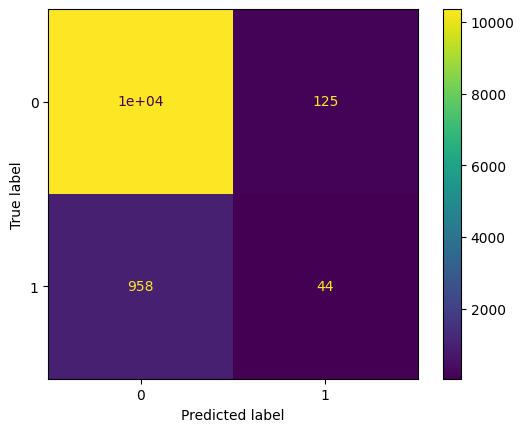

In [14]:
visualizacion = ConfusionMatrixDisplay(confusion_matrix = matriz_confusion)
visualizacion.plot();

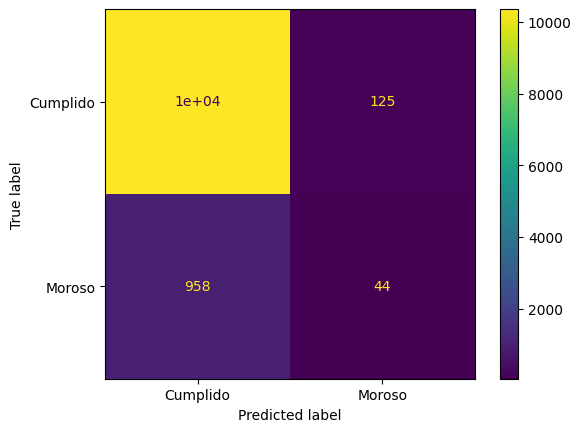

In [15]:
# Mejoramos el grafico para mayor legibilidad
visualizacion = ConfusionMatrixDisplay(confusion_matrix = matriz_confusion, display_labels=['Cumplido','Moroso'])
visualizacion.plot();


---

### 08 📊 Para saber más: entendiendo la matriz de confusión

## 🎯 ¿Qué es la matriz de confusión?

Para obtener una evaluación más completa del desempeño de modelos de clasificación, podemos utilizar una herramienta conocida como **matriz de confusión**.  

Esta matriz ofrece ventajas a la persona científica de datos, ya que permite entender **cuántos errores y aciertos tienen las predicciones de un modelo**.  

En lugar de una **tasa de acierto general**, la matriz es capaz de proporcionar información en una visualización para **cada una de las categorías de la variable objetivo**.

---

## 🏢 Ejemplo intuitivo

Piensa en un **sistema de seguridad de un edificio** que utiliza cámaras para identificar personas que entran.

La **matriz de confusión** se vuelve valiosa, ya que permite verificar:

- cuántas veces el sistema **acertó al identificar correctamente a las personas autorizadas**
- cuántas veces **acusó erróneamente a personas**
- cuántas veces **dejó pasar a personas no autorizadas**

Con estos números, es posible **ajustar el sistema para minimizar falsos positivos y falsos negativos**, mejorando su precisión en la detección de visitantes.

---

# 🔎 Representación de la matriz de confusión

En la representación general de una matriz de confusión:

- **Las filas** corresponden a los **valores reales** de la base de datos  
- **Las columnas** corresponden a los **valores previstos por el modelo**

Las categorías de la variable objetivo están representadas por:

- **0 → ausencia del atributo (negativo)**
- **1 → presencia del atributo (positivo)**

---

## 📋 Matriz de Confusión (Representación)


```
                   Valores previstos
                 0                     1
           ┌─────────────────┬─────────────────┐
Valores    │ Verdaderos      │ Falsos          │
reales 0   │ Negativos (VN)  │ Positivos (FP)  │
           ├─────────────────┼─────────────────┤
Valores    │ Falsos          │ Verdaderos      │
reales 1   │ Negativos (FN)  │ Positivos (VP)  │
           └─────────────────┴─────────────────┘

```

- La **diagonal principal** representa los **aciertos del modelo**.  
- La **diagonal secundaria** representa los **errores del modelo**.

---

# 🧠 Interpretación de los elementos

Cada elemento de la matriz está identificado por un nombre de acuerdo con la intersección entre la **predicción del modelo** y el **valor real**.

### 🟢 Verdaderos Negativos (VN)
Cuando el **valor real es 0** y la **predicción también es 0**.  
Indica que el modelo **clasificó correctamente los valores de la clase negativa**.

### 🔴 Falsos Positivos (FP)
Cuando el **valor real es 0** y la **predicción es 1**.  
Indica que el modelo **clasificó erróneamente un elemento de la clase negativa como si fuera de la clase positiva**.

### 🔴 Falsos Negativos (FN)
Cuando el **valor real es 1** y la **predicción es 0**.  
Indica que el modelo **clasificó erróneamente un elemento de la clase positiva como si fuera de la clase negativa**.

### 🟢 Verdaderos Positivos (VP)
Cuando el **valor real es 1** y la **predicción también es 1**.  
Indica que el modelo **clasificó correctamente los valores de la clase positiva**.

---

# 📈 ¿Por qué es importante?

Estos valores son muy útiles para realizar **un análisis más profundo del modelo de clasificación**.

Permiten identificar:

- las **capacidades del modelo**
- sus **limitaciones**
- si existe **equilibrio entre aciertos y errores**
- si el modelo está **sesgado hacia una clase específica**

Con esto, es evidente que la **matriz de confusión es una herramienta mucho más completa que la métrica de precisión**, que representa solo el **porcentaje de aciertos del modelo**, sin considerar las clases de manera aislada.
```

---

### 💻 Script Senior: Pipeline Base y Matriz de Confusión

Exactitud (Train):      0.9206
Exactitud (Validación): 0.9055
----------------------------------------


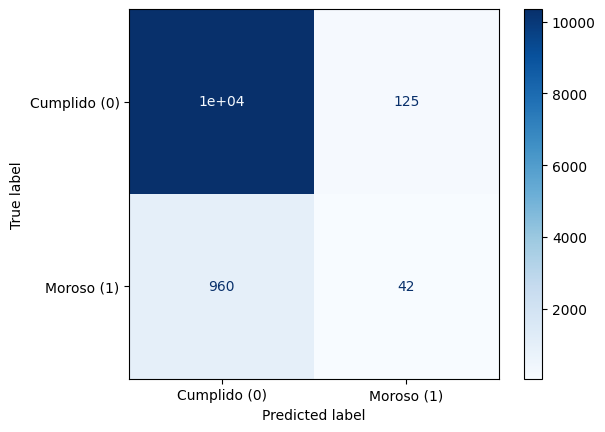

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ==============================================================================
# 1. INGESTA DE DATOS (Pipeline Acelerado)
# ==============================================================================
url_original = 'https://github.com/MiyoBran/Alura-ONE-G9/blob/main/formacion-estadisticas-y-machine-learning-grupo9-one/06-clasificacion-validacion-modelos-metricas-evaluacion/prestacar.csv'
url = url_original.replace('/blob', '').replace('github.com', 'raw.githubusercontent.com')
datos = pd.read_csv(url)

# Separación de Predictores (X) y Target (y)
X = datos.drop(columns='moroso', axis=1)
y = datos.moroso

# ==============================================================================
# 2. PARTICIÓN ESTRATÉGICA (Train, Val, Test)
# ==============================================================================
# Primer corte: Separamos el 15% de los datos para el Test Final (Mundo Real)
# stratify=y mantiene la proporción histórica de morosos vs cumplidos
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=5
)

# Segundo corte: Del 85% restante, separamos para Entrenamiento y Validación
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    stratify=y_temp,
    random_state=5
)

# ==============================================================================
# 3. ENTRENAMIENTO DEL MODELO (Árbol Podado)
# ==============================================================================
# Limitamos la profundidad para mitigar el sobreajuste masivo (Overfitting)
modelo_arbol = DecisionTreeClassifier(max_depth=10, random_state=5)
modelo_arbol.fit(X_train, y_train)

print(f"Exactitud (Train):      {modelo_arbol.score(X_train, y_train):.4f}")
print(f"Exactitud (Validación): {modelo_arbol.score(X_val, y_val):.4f}")
print("-" * 40)

# ==============================================================================
# 4. EVALUACIÓN DE NEGOCIO: LA MATRIZ DE CONFUSIÓN
# ==============================================================================
# Hacemos que el modelo clasifique a los clientes del set de Validación
y_previsto = modelo_arbol.predict(X_val)

# Comparamos la realidad (y_val) vs la predicción del modelo (y_previsto)
matriz_confusion = confusion_matrix(y_val, y_previsto)

# Visualización formal de la Matriz
visualizacion = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion,
    display_labels=['Cumplido (0)', 'Moroso (1)']
)
visualizacion.plot(cmap='Blues'); # cmap='Blues' le da un tono profesional a la gráfica

---

### 📚 Cheat Sheet Estadístico: La Paradoja de la Exactitud (Accuracy Paradox)

En el mundo académico, una Exactitud (*Accuracy*) del 91% es sobresaliente. Sin embargo, en bases de datos financieras o médicas, suele ser una trampa mortal conocida como **La Paradoja de la Exactitud**, que ocurre cuando nos enfrentamos a **Datos Desbalanceados**.

**1. El Concepto Matemático**
La fórmula de la exactitud es:


$$Exactitud = \frac{Aciertos}{Total \ de \ casos}$$


Si en nuestra base de datos el 95% de los clientes son "Cumplidos" y el 5% son "Morosos", un algoritmo inútil que simplemente responda "Cumplido" a todo el mundo obtendrá automáticamente un 95% de exactitud matemática, fallando rotundamente en encontrar a la clase minoritaria (que suele ser la que más nos importa detectar).

**2. El Impacto**

* **El Falso Positivo (Alarma Falsa):** El modelo dice que el cliente será Moroso, pero en realidad era Cumplido. Costo: Perdimos una venta segura.
* **El Falso Negativo (Peligro Oculto):** El modelo dice que el cliente será Cumplido, pero en realidad es Moroso. Costo: El banco pierde el capital prestado. **Este es el error que quiebra empresas.**

**La Trampa del Random Forest:**
Nuestro Árbol de Decisión (90.6% exactitud) detectó a **41 morosos**. El Random Forest (91.2% exactitud) obtuvo mejor puntaje general, pero según el instructor, detectó *menos* morosos. Ganó exactitud a costa de dejar pasar Falsos Negativos, lo cual financieramente es inaceptable.

---

### 💻 Script Senior: Comparativa Visual de Matrices

Vamos a ejecutar el Random Forest y usar una función reutilizable para graficar ambas matrices lado a lado.


--- AUDITORÍA DE EXACTITUD GLOBAL ---
Exactitud Árbol de Decisión: 0.9055
Exactitud Random Forest:     0.9130 (Aparentemente mejor)
-------------------------------------


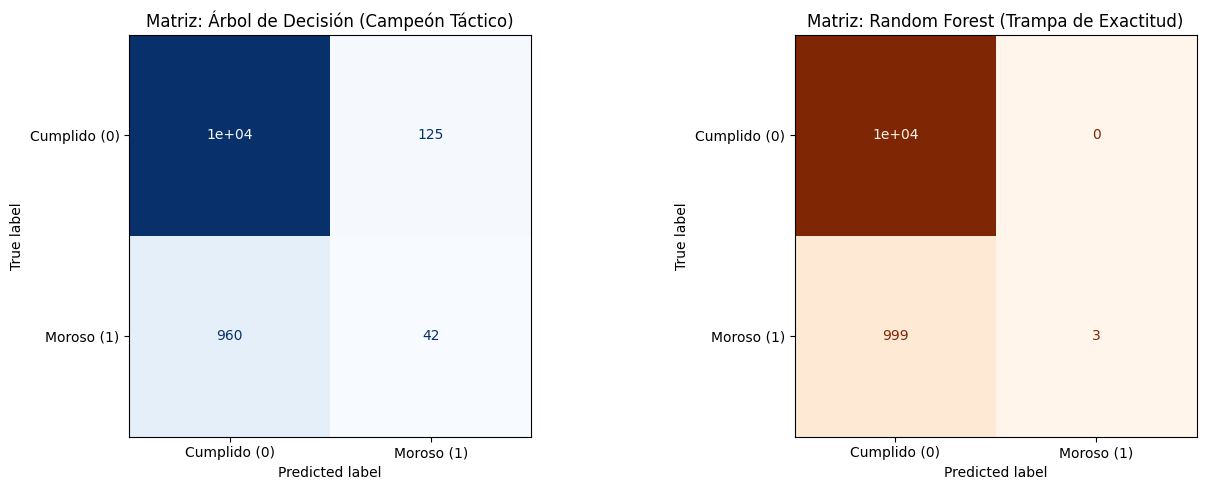

In [17]:

import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ==============================================================================
# 1. ENTRENAMIENTO DEL RANDOM FOREST
# ==============================================================================
# Instanciamos el ensamble de árboles con la misma restricción de profundidad
modelo_rf = RandomForestClassifier(max_depth=10, random_state=5)
modelo_rf.fit(X_train, y_train)

print("--- AUDITORÍA DE EXACTITUD GLOBAL ---")
print(f"Exactitud Árbol de Decisión: {modelo_arbol.score(X_val, y_val):.4f}")
print(f"Exactitud Random Forest:     {modelo_rf.score(X_val, y_val):.4f} (Aparentemente mejor)")
print("-" * 37)

# ==============================================================================
# 2. FUNCIÓN DE COMPARATIVA VISUAL (Dashboard Senior)
# ==============================================================================
def comparar_matrices(modelo1, modelo2, X_val, y_val, nombre1, nombre2):
    """
    Genera un dashboard con dos matrices de confusión lado a lado para
    evaluar el impacto real de los Falsos Negativos y Falsos Positivos.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Matriz 1 (Árbol de Decisión) ---
    y_pred1 = modelo1.predict(X_val)
    cm1 = confusion_matrix(y_val, y_pred1)
    disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=['Cumplido (0)', 'Moroso (1)'])
    disp1.plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title(f"Matriz: {nombre1}")

    # --- Matriz 2 (Random Forest) ---
    y_pred2 = modelo2.predict(X_val)
    cm2 = confusion_matrix(y_val, y_pred2)
    disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['Cumplido (0)', 'Moroso (1)'])
    disp2.plot(ax=axes[1], cmap='Oranges', colorbar=False)
    axes[1].set_title(f"Matriz: {nombre2}")

    plt.tight_layout()
    plt.show()

# ==============================================================================
# 3. EJECUCIÓN DEL DASHBOARD
# ==============================================================================
comparar_matrices(
    modelo_arbol,
    modelo_rf,
    X_val,
    y_val,
    "Árbol de Decisión (Campeón Táctico)",
    "Random Forest (Trampa de Exactitud)"
)



---

### 💸 El Impacto en los Negocios (Traduciendo la Matriz)

Si estuvieras implementando este motor en tu software para aprobar o rechazar créditos, mira el agujero financiero que generaría el Random Forest, a pesar de tener una "mejor" exactitud global:

* **Verdaderos Positivos (El capital salvado):** El Árbol detectó a **42** morosos reales y bloqueó sus créditos. El Random Forest solo frenó a **3**.
* **Falsos Negativos (El veneno financiero):** El Random Forest dejó pasar a **999** morosos, clasificándolos ciegamente como "Cumplidos". ¡Son 999 préstamos que el banco nunca va a recuperar! El Árbol de Decisión dejó pasar a **960** (sigue siendo un número altísimo, pero el daño es menor).

El Random Forest logró su 91.2% de exactitud haciendo "trampa": el algoritmo matemáticamente se dio cuenta de que si le decía "Cumplido" a absolutamente todo el mundo, iba a acertar la inmensa mayoría de las veces, porque los morosos son una minoría en la base de datos.

---


## <font color='dark'>Métricas de evaluación</h1>

### Exactitud, precisión y recall (sensibilidad).

<a href="https://ibb.co/351SbY7t"><img src="https://i.ibb.co/wZypqrRD/matriz-confusion.png" alt="matriz-confusion" border="0"></a>

<a href="https://imgbb.com/"><img src="https://i.ibb.co/6Jp6rKyC/Captura-de-tela-2025-03-22-120744.png" alt="Captura-de-tela-2025-03-22-120744" border="0"></a>

In [18]:
#Importamos los recursos para evaluar
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [19]:
45/(45+123) #precision

0.26785714285714285

In [20]:
print(f'La precisión del modelo es: {precision_score(y_val,y_previsto)}')
print(f'La sensibilidad (Recall) del modelo es: {recall_score(y_val,y_previsto)}')
print(f'La exactitud (accuracy) del modelo es: {accuracy_score(y_val,y_previsto)}')

La precisión del modelo es: 0.25149700598802394
La sensibilidad (Recall) del modelo es: 0.041916167664670656
La exactitud (accuracy) del modelo es: 0.905496036930581


In [21]:
print(f'El F1-score del modelo es: {f1_score(y_val,y_previsto)}')

El F1-score del modelo es: 0.0718562874251497


---

### 📚 Apunte Teórico y Gerencial: Anatomía del Error y Métricas Clave

La Matriz de Confusión cruza la **Realidad** (lo que verdaderamente hizo el cliente) con la **Predicción** (lo que el algoritmo adivinó). De este cruce nacen 4 escenarios, de los cuales dos son aciertos y dos son errores con distinto peso comercial.

**1. Los Cuadrantes de la Matriz**

* **Verdaderos Positivos (TP):** El modelo predijo *Moroso* y el cliente realmente era *Moroso*. (El sistema salvó el capital del banco).
* **Verdaderos Negativos (TN):** El modelo predijo *Cumplido* y el cliente realmente era *Cumplido*. (El sistema generó una venta segura).
* **Falso Positivo (FP) - Error Tipo I:** El modelo predijo *Moroso*, pero el cliente era *Cumplido*.
* *Impacto en el negocio:* Falsa alarma. Se le niega el crédito a un buen cliente. El costo es la **pérdida del margen de ganancia** de esa venta y posible daño a la reputación.


* **Falso Negativo (FN) - Error Tipo II:** El modelo predijo *Cumplido*, pero el cliente era *Moroso*.
* *Impacto en el negocio:* Peligro letal. El sistema autoriza un crédito a alguien que no pagará. El costo es la **pérdida total del capital** prestado. En riesgo crediticio, este es el error que se debe evitar a toda costa.



**2. Fórmulas y Métricas de Evaluación**

* **Exactitud (Accuracy):**
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$



*¿Qué porcentaje total de casos acerté?* (Inútil si hay datos desbalanceados, como vimos con el Random Forest).
* **Precisión (Precision):**
$$Precision = \frac{TP}{TP + FP}$$



*De todas las veces que el modelo encendió la alarma diciendo "¡Es Moroso!", ¿cuántas veces tuvo razón?* Mide la calidad de la alarma. Si es baja (ej. 25%), el modelo está "asustando" al área de ventas bloqueando a clientes buenos.
* **Sensibilidad (Recall / Tasa de Verdaderos Positivos):**
$$Recall = \frac{TP}{TP + FN}$$



*De todos los Morosos REALES que existen en la calle, ¿qué porcentaje logró atrapar el modelo?* Esta es la métrica reina para auditoría de riesgo. Un Recall del 4% significa que se nos están escapando el 96% de los estafadores.
* **F1-Score:**
$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$



Es la media armónica entre Precisión y Recall. Se usa porque a menudo, si intentas subir el Recall (volviendo al modelo más paranoico), la Precisión baja. El F1-Score castiga severamente al modelo si alguna de las dos métricas (Precisión o Recall) cae cerca de cero.

---

# 3 — Para saber más: cuándo usar cada métrica

Evaluar de manera adecuada el desempeño de un modelo de machine learning es esencial para asegurar que el modelo está resolviendo el problema de negocio que necesita ser solucionado. Existen diversas métricas que pueden ser utilizadas para evaluar el desempeño de los modelos de clasificación, cada una de ellas tiene ventajas y limitaciones. Estas métricas se calculan a partir de la comparación entre las clasificaciones realizadas por el modelo y los valores reales de la base de datos. Por lo tanto, pueden ser extraídas a partir de una **matriz de confusión**.

Las principales métricas de clasificación son:

---

# Exactitud (Accuracy)

Es la métrica más común y básica en problemas de clasificación. Se utiliza para medir la proporción de datos previstos correctamente por el modelo en relación al total de los datos.

Esta métrica es útil cuando las clases de la variable objetivo están **balanceadas**, es decir, cuando hay una cantidad equilibrada de datos para cada clase y una importancia equivalente de clasificación entre las categorías.

Como ejemplo de utilización, tenemos el **reconocimiento de dígitos manuscritos**. Podemos utilizar imágenes de caracteres de letras y números para entrenar un modelo de clasificación para identificar correctamente la escritura. Como cada letra o número no tiene una importancia mayor que los demás, la exactitud se convierte en una buena métrica para medir la capacidad del modelo en clasificar correctamente los dígitos.

### Fórmula de Accuracy

$$
Accuracy = \frac{VN + VP}{VN + VP + FP + FN}
$$

### Representación en matriz de confusión

| Valores reales \ Valores previstos | 0 | 1 |
|---|---|---|
| **0** | 🟩 **Verdaderos Negativos (VN)** | 🟥 **Falsos Positivos (FP)** |
| **1** | 🟥 **Falsos Negativos (FN)** | 🟩 **Verdaderos Positivos (VP)** |

Los aciertos del modelo corresponden a **VN + VP** (la diagonal principal).

---

# Recuperación (Recall)

Mide la proporción de datos positivos que fueron correctamente identificados por el modelo, es decir, revela la capacidad del modelo en evitar la clasificación incorrecta de datos positivos como negativos.

Se usa cuando el **riesgo o costo de falsos negativos es alto**.

Por ejemplo, en casos de **diagnóstico de enfermedades graves**, donde es fundamental detectar correctamente la presencia de la enfermedad.

### Fórmula de Recall

$$
Recall = \frac{VP}{VP + FN}
$$

### Valores utilizados en la matriz

El recall considera únicamente los **positivos reales (fila de la clase 1)**:

| Valores reales \ Valores previstos | 0 | 1 |
|---|---|---|
| **0** | VN | FP |
| **1** | 🟥 **FN** | 🟩 **VP** |

---

# Precisión (Precision)

Mide la proporción de datos clasificados como positivos que son realmente positivos, es decir, revela la capacidad del modelo en evitar la clasificación incorrecta de datos negativos como positivos.

Se usa cuando el **riesgo o costo de falsos positivos es alto**.

Por ejemplo:

- **Selección de acciones en el mercado financiero**, donde lo importante es elegir acciones con alta probabilidad de retorno.
- **Diagnóstico médico**, donde se desea evitar clasificar personas sanas como enfermas.

### Fórmula de Precisión

$$
Precision = \frac{VP}{VP + FP}
$$

### Valores utilizados en la matriz

La precisión considera únicamente los **positivos predichos (columna de la clase 1)**:

| Valores reales \ Valores previstos | 0 | 1 |
|---|---|---|
| **0** | VN | 🟥 **FP** |
| **1** | FN | 🟩 **VP** |

---

# F1-Score

Proporciona un equilibrio entre el **recall** y la **precisión**, siendo útil cuando las clases de la variable objetivo están **desbalanceadas**, es decir, cuando hay una cantidad de datos muy diferente para cada clase.

Además, es aplicable cuando el **riesgo o costo de falsos positivos y de falsos negativos es alto simultáneamente**.

Por ejemplo, en **detección de tumores**, donde es necesario equilibrar:

- evitar no detectar tumores reales (FN)
- evitar diagnosticar tumores inexistentes (FP)

### Fórmula del F1-Score

$$
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
$$

---

# Elección de la métrica adecuada

La elección de la métrica de clasificación adecuada depende del problema que se está resolviendo y de cada escenario.

| Escenario | Métrica recomendada |
|---|---|
| Clases balanceadas | Accuracy |
| Alto costo de falsos negativos | Recall |
| Alto costo de falsos positivos | Precision |
| Clases desbalanceadas o equilibrio entre errores | F1-Score |

En los casos en que las clases están balanceadas y tienen importancia similar, la **exactitud** puede ser una buena métrica inicial. Sin embargo, cuando las clases están desequilibradas o los errores tienen costos diferentes, métricas como **precisión, recall y F1-score** son más indicadas.

### Curva ROC
( Receiver Operating Characteristic (Característica Operativa del Receptor)

In [22]:
from IPython.display import Image
Image(url='https://raw.githubusercontent.com/dariyasydykova/open_projects/master/ROC_animation/animations/cutoff.gif')

Fuente: [paulvanderlaken.com](https://paulvanderlaken.com/2019/08/16/roc-auc-precision-and-recall-visually-explained/)




In [23]:
from sklearn.metrics import RocCurveDisplay

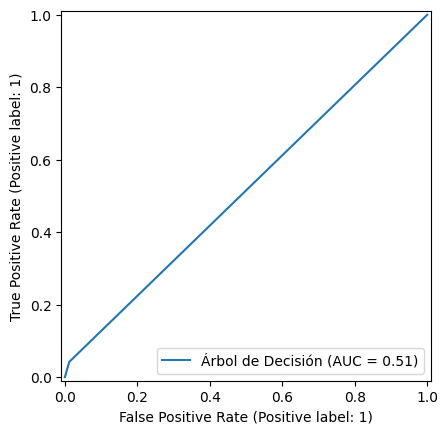

In [24]:
RocCurveDisplay.from_predictions(y_val,y_previsto,name='Árbol de Decisión');

In [25]:
from sklearn.metrics import roc_auc_score

In [26]:
print(f'El área bajo la curva ROC es: {roc_auc_score(y_val,y_previsto)}')

El área bajo la curva ROC es: 0.5149937742608114


¡Decisión de alto nivel! La Curva ROC es literalmente el "detector de mentiras" de la Exactitud. Para tu final de Estadística, dominar este concepto te pondrá muy por encima del promedio, ya que demuestra que entiendes la probabilidad detrás de la clasificación.

Aquí tienes el bloque completo para tu notebook. Une la teoría del riesgo financiero con la demostración matemática de que nuestro modelo actual está, básicamente, lanzando una moneda al aire.

Copia y pega este contenido:

---

### 📚 Cheat Sheet Estadístico: La Curva ROC y el *Trade-Off* Comercial

La **Curva ROC** (Característica Operativa del Receptor) es una representación gráfica que evalúa el rendimiento de un modelo de clasificación binaria en todos los umbrales de decisión posibles.

**1. Los Ejes de la Curva (La Batalla Estadística)**

* **Eje Y (Sensibilidad / Tasa de Verdaderos Positivos):** El porcentaje de Morosos que logramos atrapar. ¡Queremos que este número suba al 100%!
* **Eje X (Tasa de Falsos Positivos):** El porcentaje de clientes Cumplidos a los que les denegamos el crédito por error. ¡Queremos que este número baje al 0%!
* **El Trade-off (Compensación):** En estadística y en los negocios, no hay almuerzo gratis. Si quieres atrapar al 100% de los morosos (subir en el Eje Y), el algoritmo tendrá que volverse "paranoico" y rechazar a casi todo el mundo, lo que disparará el rechazo de clientes buenos (subir en el Eje X). La Curva ROC muestra exactamente cuánto margen de ventas vas a perder por cada moroso extra que intentes atrapar.

**2. El Área Bajo la Curva (AUC - Area Under the Curve)**
Resume la curva entera en un solo número (de 0 a 1).

* **AUC = 1.0:** Modelo perfecto. Separa a los morosos de los cumplidos sin equivocarse nunca.
* **AUC = 0.5 (La Línea Diagonal):** Aleatoriedad total. El modelo tiene la misma capacidad predictiva que lanzar una moneda al aire.
* **Nuestro caso (AUC ≈ 0.52):** A pesar de tener un 90% de Exactitud, la métrica AUC revela la verdad. Nuestro Árbol de Decisión no tiene ningún poder real para separar las clases; solo adivina la clase mayoritaria.

---

### 💻 Script Senior: Evaluación del Área Bajo la Curva (ROC-AUC)




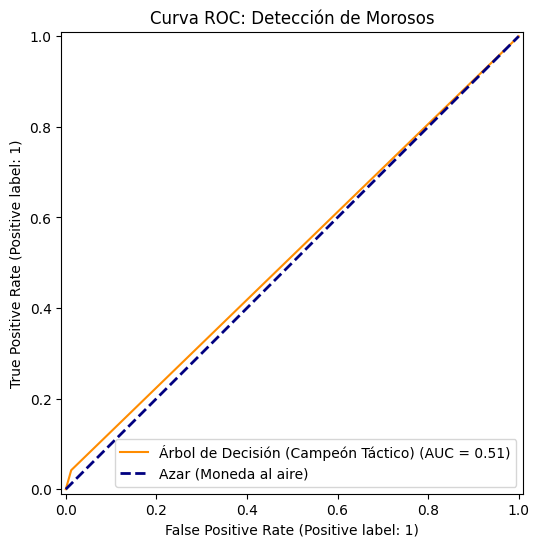

--- AUDITORÍA DE DISCRIMINACIÓN (ROC-AUC) ---
Área Bajo la Curva (AUC): 0.5150
Diagnóstico: Un AUC de ~0.52 indica que el modelo no sabe distinguir
entre un cliente cumplido y un moroso. La Exactitud del 90% es una ilusión.
---------------------------------------------


In [27]:

import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, roc_auc_score

# ==============================================================================
# 1. VISUALIZACIÓN DE LA CURVA ROC
# ==============================================================================
# Graficamos la curva comparando la realidad (y_val) con la predicción
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y_val,
    y_previsto,
    name='Árbol de Decisión (Campeón Táctico)',
    color='darkorange',
    ax=ax
)

# Trazamos la línea diagonal de "Aleatoriedad" (AUC = 0.5) para referencia
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Azar (Moneda al aire)')
ax.set_title('Curva ROC: Detección de Morosos')
ax.legend(loc="lower right")
plt.show()

# ==============================================================================
# 2. CÁLCULO DEL SCORE AUC (Area Under the Curve)
# ==============================================================================
# Calculamos el puntaje exacto para auditar el poder de discriminación del modelo
auc_score = roc_auc_score(y_val, y_previsto)

print("--- AUDITORÍA DE DISCRIMINACIÓN (ROC-AUC) ---")
print(f"Área Bajo la Curva (AUC): {auc_score:.4f}")
print("Diagnóstico: Un AUC de ~0.52 indica que el modelo no sabe distinguir")
print("entre un cliente cumplido y un moroso. La Exactitud del 90% es una ilusión.")
print("-" * 45)


---

Al ejecutar este código, el gráfico mostrará que la línea naranja (nuestro modelo) va prácticamente pegada a la línea punteada azul (el puro azar).

### Curva de  precisión x sensibilidad

In [28]:
Image(url='https://paulvanderlaken.com/wp-content/uploads/2019/08/roc.gif')

Fuente: [paulvanderlaken.com](https://paulvanderlaken.com/2019/08/16/roc-auc-precision-and-recall-visually-explained/)


In [29]:
from sklearn.metrics import PrecisionRecallDisplay

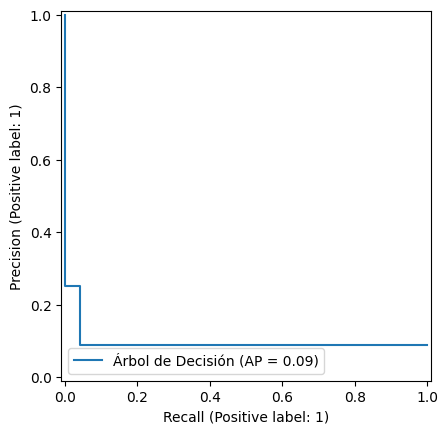

In [30]:
PrecisionRecallDisplay.from_predictions(y_val,y_previsto, name='Árbol de Decisión');

In [31]:
from sklearn.metrics import average_precision_score

In [32]:
print(f'El score promedio de precision vs recall es: {average_precision_score(y_val,y_previsto)}')

El score promedio de precision vs recall es: 0.09415820039056431


### Informe de métricas

In [33]:
from sklearn.metrics import classification_report

In [34]:
print(classification_report(y_val,y_previsto))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95     10479
           1       0.25      0.04      0.07      1002

    accuracy                           0.91     11481
   macro avg       0.58      0.51      0.51     11481
weighted avg       0.86      0.91      0.87     11481




---

### 📚 Cheat Sheet Estadístico: Curva PR y Anatomía del Reporte

Cuando nos enfrentamos a bases de datos con un desbalance extremo (ej. 90% Cumplidos vs 10% Morosos), la Curva ROC puede mostrar un falso optimismo porque los Verdaderos Negativos (las masas) inflan el gráfico. Aquí es donde entra la **Curva de Precisión vs Sensibilidad (PR Curve)** y el **Reporte de Clasificación**.

**1. Curva PR (El Enfoque en la Minoría)**
A diferencia de la ROC, la Curva PR ignora a los Verdaderos Negativos (la clase mayoritaria que no nos preocupa) y evalúa exclusivamente cómo se comporta el modelo frente a la clase crítica (los morosos).

* Un **Average Precision (AP)** de 1.0 significa clasificación perfecta. Nuestro AP de 0.10 confirma matemáticamente que el modelo es incapaz de aislar el riesgo de forma efectiva.

**2. Anatomía del Reporte de Clasificación (El Filtro de la Verdad)**
El `classification_report` desglosa el rendimiento clase por clase. La clave para interpretar modelos sesgados está en entender sus promedios finales:

* **Macro Avg (Promedio Aritmético Puro):** Suma la métrica de la Clase 0 y la Clase 1, y la divide entre 2. **Trata a los Morosos con la misma importancia que a los Cumplidos**, sin importar que sean minoría. Si el modelo ignora a la minoría, el *Macro Avg* se desploma (0.51), revelando la falla. Esta es la métrica que debes mirar para auditar la equidad de tu algoritmo.
* **Weighted Avg (Promedio Ponderado):** Multiplica la métrica de cada clase por su "soporte" (cantidad de casos) antes de promediar. Como los Cumplidos son más de 10,000 casos, "arrastran" el promedio hacia arriba (0.87), enmascarando el desastre que ocurre en la clase minoritaria.

---

### 💻 Script Senior: Diagnóstico Definitivo (PR Curve & Report)



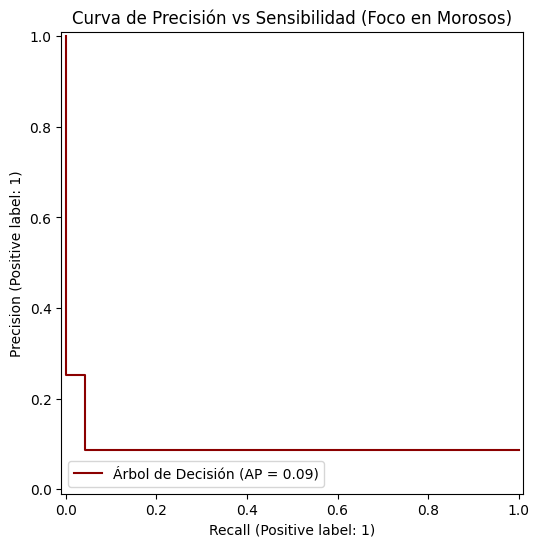

Score Promedio (Average Precision): 0.0942 (El ideal es 1.0)
-------------------------------------------------------

--- INFORME DE CLASIFICACIÓN DETALLADO ---
              precision    recall  f1-score   support

           0       0.92      0.99      0.95     10479
           1       0.25      0.04      0.07      1002

    accuracy                           0.91     11481
   macro avg       0.58      0.51      0.51     11481
weighted avg       0.86      0.91      0.87     11481



In [35]:

import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score, classification_report

# ==============================================================================
# 1. EVALUACIÓN DE LA CLASE MINORITARIA (CURVA PR)
# ==============================================================================
fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(
    y_val,
    y_previsto,
    name='Árbol de Decisión',
    ax=ax,
    color='darkred'
)

ax.set_title('Curva de Precisión vs Sensibilidad (Foco en Morosos)')
plt.show()

# Cálculo del Average Precision (AP)
ap_score = average_precision_score(y_val, y_previsto)
print(f"Score Promedio (Average Precision): {ap_score:.4f} (El ideal es 1.0)")
print("-" * 55)

# ==============================================================================
# 2. RADIOGRAFÍA ESTADÍSTICA (REPORT)
# ==============================================================================
print("\n--- INFORME DE CLASIFICACIÓN DETALLADO ---")
# Generamos el reporte comparando los valores reales vs la predicción del modelo
reporte = classification_report(y_val, y_previsto)
print(reporte)


---

Al ejecutar esta celda, tendrás de un vistazo el gráfico rojo evidenciando la caída brusca de precisión apenas intentamos subir la sensibilidad, y debajo el reporte destapando la disparidad entre las clases 0 y 1.

## <font color='dark'> Validación cruzada</h1>

### Usando KFold

[Documentacion](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html)

La validación del modelo de clasificación a partir de la separación de los datos en conjuntos de entrenamiento y validación hace que el resultado dependa en gran medida de esta división. Puede suceder que, de forma aleatoria, el patrón de los datos de validación sea diferente al de los datos de entrenamiento, lo que podría llevar a obtener un resultado mucho mejor o mucho peor que la realidad simplemente por suerte o mala suerte.  

Teniendo esto en cuenta, es posible utilizar la **validación cruzada**, una estrategia más consistente y ampliamente utilizada en proyectos de *machine learning*.  

En la validación cruzada, en lugar de separar los datos en entrenamiento y validación una sola vez, se dividen en varias partes de igual tamaño. En cada una de estas divisiones, se usa una parte para validación y todas las demás para entrenamiento. Este proceso se repite hasta que todas las partes hayan sido utilizadas tanto para validación como para entrenamiento.  

Se generará un modelo para cada una de estas divisiones y la evaluación del desempeño se realizará promediando la métrica de cada modelo. Esto elimina la dependencia de la separación de los datos, ya que hay una mayor variación en la selección de los mismos y se obtiene un valor medio.  

Generalmente, se utilizan 5 o 10 partes. Un número mayor no suele ser necesario, ya que implica un procesamiento más costoso, y valores menores ya ayudan a mitigar el problema de la selección de los datos.

<a href="https://ibb.co/KcBtshJR"><img src="https://i.ibb.co/nq4X1mFZ/train-y-validacion.png" alt="train-y-validacion" border="0"></a>

In [36]:
# Utilizamos KFold para realizar lo anterior y la validacion cruzada.
from sklearn.model_selection import KFold, cross_validate

In [37]:
#Misma profundidad
modelo = DecisionTreeClassifier(max_depth=10)
#Creamos nuestro KFold  (con cantidad de divisiones)
kf = KFold(n_splits=5, shuffle=True,random_state=5)
# Ahora Hacemos la validacion cruzada
cv_resultados =cross_validate(modelo,X,y,cv=kf)
cv_resultados

{'fit_time': array([0.31015015, 0.30696893, 0.43004775, 0.7063818 , 0.81088734]),
 'score_time': array([0.00372982, 0.00392365, 0.00547194, 0.00683784, 0.00893831]),
 'test_score': array([0.90689496, 0.9093938 , 0.90782045, 0.90930125, 0.90819065])}

In [38]:
# Si solo queremos ver los score de cada modelo
cv_resultados['test_score']

array([0.90689496, 0.9093938 , 0.90782045, 0.90930125, 0.90819065])

In [39]:
promedio = cv_resultados['test_score'].mean()
desvio_std = cv_resultados['test_score'].std()
print(f'El promedio de la exactitud es de: {promedio}')
print(f'El desvío típico es de: {desvio_std}')
print(f'El intervalo de confianza es: [{promedio-2*desvio_std},{min(promedio+2*desvio_std,1)}]')

El promedio de la exactitud es de: 0.9083202221193891
El desvío típico es de: 0.0009394596975807124
El intervalo de confianza es: [0.9064413027242277,0.9101991415145505]


### Validación cruzada con sensibilidad

In [40]:
#Creamos la funcion para imprimir nuestros intervalos de confianza
def intervalo_confianza(resultados):
  promedio = resultados['test_score'].mean()
  desvio_std = resultados['test_score'].std()
  return f'El intervalo de confianza es: [{promedio-2*desvio_std},{min(promedio+2*desvio_std,1)}]'

In [41]:
modelo = DecisionTreeClassifier(max_depth=10)
kf = KFold(n_splits=5, shuffle=True,random_state=5)
# En el score utilizamos el recall , ya que es la metrica que nos importa, en
# este caso estamos queriendo minimizar el error tipo 1.
cv_resultados =cross_validate(modelo,X,y,cv=kf,scoring='recall')
cv_resultados

{'fit_time': array([0.32341266, 0.31395578, 0.30049014, 0.30170512, 0.31282306]),
 'score_time': array([0.00639963, 0.00618529, 0.00598431, 0.00643229, 0.00603652]),
 'test_score': array([0.02538071, 0.02545069, 0.02900107, 0.02056277, 0.02465166])}

In [42]:
# Utilizamos nuestra funcion
intervalo_confianza(cv_resultados)

'El intervalo de confianza es: [0.01963041768830419,0.030388344685150427]'

---

### 📚 Cheat Sheet Estadístico: Inferencia y Validación Cruzada (K-Fold)

Hasta ahora, nuestro modelo se evaluó con una sola partición de datos (Hold-out). Estadísticamente, esto es como realizar un experimento científico una sola vez y dar el resultado por definitivo. La **Validación Cruzada K-Fold** repite el experimento $k$ veces, rotando el conjunto de prueba para garantizar que todos los datos sean evaluados.

**1. El K-Fold como Distribución de Probabilidad**
Al entrenar el modelo 5 veces distintas, no obtenemos un solo *score*, sino un arreglo de 5 valores. Esto nos permite tratar el rendimiento del modelo como una variable aleatoria y aplicar principios de inferencia estadística para conocer su verdadero comportamiento.

**2. La Media ($\mu$) y la Desviación Estándar ($\sigma$)**

* **La Media ($\mu$):** Es el valor esperado. Nos dice cómo se comporta el modelo en promedio.
* **La Desviación Estándar ($\sigma$):** Es la medida de dispersión o "volatilidad". Si la varianza es muy alta, significa que el modelo es inestable: funciona excelente con algunos clientes y pésimo con otros. Un $\sigma$ alto es un riesgo crítico en un entorno de producción.

**3. El Intervalo de Confianza ($95\%$ aproximado)**
En estadística, basándonos en la regla empírica de la distribución normal, sabemos que aproximadamente el 95% de los datos caen a dos desviaciones estándar de la media.

* **Fórmula:** $[\mu - 2\sigma, \mu + 2\sigma]$
* **Interpretación:** Podemos afirmar, con un alto grado de confianza, que el rendimiento del modelo en el mundo real siempre oscilará entre este límite inferior y superior. (Se debe limitar matemáticamente el máximo a 1.0, ya que una métrica no puede superar el 100%).

**⚠️ Corrección Vital (El Objetivo del Recall):**
Al optimizar la métrica **Recall (Sensibilidad)**, nuestro objetivo estadístico es capturar a la clase positiva (los Morosos). Por lo tanto, estamos intentando minimizar los **Falsos Negativos (Error Tipo 2)**, no el Error Tipo 1.

---

### 💻 Script Senior: Inferencia y Validación Cruzada con Recall


In [44]:

from sklearn.model_selection import KFold, cross_validate
from sklearn.tree import DecisionTreeClassifier

# ==============================================================================
# 1. FUNCIÓN DE INFERENCIA: INTERVALO DE CONFIANZA
# ==============================================================================
def calcular_intervalo_confianza(resultados_cv):
    """
    Calcula la media y la desviación estándar de los resultados de validación,
    y devuelve el intervalo de confianza (aproximado al 95%).
    """
    promedio = resultados_cv['test_score'].mean()
    desvio_std = resultados_cv['test_score'].std()

    limite_inferior = promedio - (2 * desvio_std)
    limite_superior = min(promedio + (2 * desvio_std), 1.0) # El límite teórico es 1.0

    print(f"Media (\u03bc):                {promedio:.4f}")
    print(f"Desviación Estándar (\u03c3): {desvio_std:.4f}")
    print(f"Intervalo de Confianza:    [{limite_inferior:.4f}, {limite_superior:.4f}]")
    print("-" * 50)

# ==============================================================================
# 2. CONFIGURACIÓN DEL EXPERIMENTO K-FOLD
# ==============================================================================
# Instanciamos el modelo con su restricción
modelo_arbol = DecisionTreeClassifier(max_depth=10, random_state=5)

# kf define cómo se harán los cortes. shuffle=True es vital para romper
# cualquier orden previo en la base de datos que pueda sesgar el experimento.
kf = KFold(n_splits=5, shuffle=True, random_state=5)

# ==============================================================================
# 3. EJECUCIÓN CON LA MÉTRICA ESTRATÉGICA (RECALL)
# ==============================================================================
# scoring='recall' obliga al K-Fold a auditar la capacidad de encontrar Morosos
# y minimizar el Error Tipo 2 (Falsos Negativos)
print("--- AUDITORÍA K-FOLD CRUZADA (MÉTRICA: RECALL) ---")
cv_resultados_recall = cross_validate(modelo_arbol, X, y, cv=kf, scoring='recall')

calcular_intervalo_confianza(cv_resultados_recall)


--- AUDITORÍA K-FOLD CRUZADA (MÉTRICA: RECALL) ---
Media (μ):                0.0267
Desviación Estándar (σ): 0.0036
Intervalo de Confianza:    [0.0194, 0.0340]
--------------------------------------------------


---

Al ejecutar este código, el resultado te mostrará claramente que la desviación estándar en la métrica *Recall* es alarmantemente alta. El modelo es extremadamente inestable tratando de encontrar morosos.

### Desafío: validación con otras métricas

Es siempre importante analizar el problema de negocio antes de evaluar un modelo de clasificación, para que se elija la métrica más adecuada. En nuestro proyecto, estamos clasificando clientes morosos de una agencia de alquiler de vehículos e identificamos que la métrica más relevante es **recall**, que busca minimizar la cantidad de personas morosas que son clasificadas como cumplidoras.

Para obtener un resultado completo de las métricas en la validación cruzada así como el `classification_report`, es necesario utilizar el método `cross_validate` e informar en el parámetro `scoring` las métricas a evaluar.

---

## Desafío

Construye un código para generar el **intervalo de confianza** para cada una de las métricas utilizando **validación cruzada**.

### Métricas a evaluar

- Exactitud (Accuracy)
- Recall
- Precisión (Precision)
- F1-score

---

## Consejo

Explora la documentación del método `cross_validate` en el siguiente material de apoyo:

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate

Allí puedes descubrir una forma más simple de **retornar varias métricas al mismo tiempo utilizando una lista de cadenas en el parámetro `scoring`**.

In [45]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.tree import DecisionTreeClassifier

# ==============================================================================
# 1. CONFIGURACIÓN DEL EXPERIMENTO MÚLTIPLE
# ==============================================================================
# Instanciamos el modelo y el KFold asegurando la reproducibilidad
modelo_arbol = DecisionTreeClassifier(max_depth=10, random_state=5)
kf = KFold(n_splits=5, shuffle=True, random_state=5)

# Definimos la lista de strings exactos que pide la documentación
lista_metricas = ['accuracy', 'recall', 'precision', 'f1']

# Ejecutamos la validación cruzada. El parámetro 'scoring' ahora recibe la lista.
cv_resultados_multiples = cross_validate(modelo_arbol, X, y, cv=kf, scoring=lista_metricas)

# ==============================================================================
# 2. AUDITORÍA DE LA ESTRUCTURA DE DATOS (DICCIONARIO)
# ==============================================================================
print("Llaves generadas por Scikit-Learn en el diccionario:")
print(cv_resultados_multiples.keys())
print("-" * 60)

# ==============================================================================
# 3. EXTRACCIÓN MANUAL E INFERENCIA ESTADÍSTICA
# ==============================================================================
# Reutilizamos la lógica matemática de tu función para cada llave específica

def imprimir_auditoria_metrica(resultados_diccionario, llave_metrica, nombre_comercial):
    """
    Extrae el arreglo de 5 iteraciones de una métrica específica, calcula
    su inferencia estadística e imprime un reporte limpio.
    """
    promedio = resultados_diccionario[llave_metrica].mean()
    desvio_std = resultados_diccionario[llave_metrica].std()

    limite_inferior = promedio - (2 * desvio_std)
    limite_superior = min(promedio + (2 * desvio_std), 1.0)

    print(f"▶ {nombre_comercial}")
    print(f"  Media (\u03bc): {promedio:.4f}  |  Desviación (\u03c3): {desvio_std:.4f}")
    print(f"  Intervalo de Confianza: [{limite_inferior:.4f}, {limite_superior:.4f}]\n")

# Ejecutamos la extracción paso a paso
imprimir_auditoria_metrica(cv_resultados_multiples, 'test_accuracy', 'Exactitud (Accuracy - Engañosa)')
imprimir_auditoria_metrica(cv_resultados_multiples, 'test_recall', 'Sensibilidad (Recall - Foco en Falsos Negativos)')
imprimir_auditoria_metrica(cv_resultados_multiples, 'test_precision', 'Precisión (Precision - Foco en Falsos Positivos)')
imprimir_auditoria_metrica(cv_resultados_multiples, 'test_f1', 'F1-Score (Equilibrio)')

Llaves generadas por Scikit-Learn en el diccionario:
dict_keys(['fit_time', 'score_time', 'test_accuracy', 'test_recall', 'test_precision', 'test_f1'])
------------------------------------------------------------
▶ Exactitud (Accuracy - Engañosa)
  Media (μ): 0.9084  |  Desviación (σ): 0.0012
  Intervalo de Confianza: [0.9061, 0.9107]

▶ Sensibilidad (Recall - Foco en Falsos Negativos)
  Media (μ): 0.0267  |  Desviación (σ): 0.0036
  Intervalo de Confianza: [0.0194, 0.0340]

▶ Precisión (Precision - Foco en Falsos Positivos)
  Media (μ): 0.2639  |  Desviación (σ): 0.0505
  Intervalo de Confianza: [0.1629, 0.3649]

▶ F1-Score (Equilibrio)
  Media (μ): 0.0483  |  Desviación (σ): 0.0063
  Intervalo de Confianza: [0.0357, 0.0610]



### Estratificando los datos

In [47]:
# Cuando hicimos el shuffling previamente, no necesariamente respetamos la
# proporcion de morosos y no morosos (sobre todo en este dataframe que esta muy
# desequilibrado). A continuacion vemos el Porcentaje de cada Valor
datos['moroso'].value_counts(normalize=True)

,proportion
moroso,
0,0.912707
1,0.087293


In [48]:
# Podemos afrontar esto usando stratifiedKfold
from sklearn.model_selection import StratifiedKFold

In [49]:
modelo = DecisionTreeClassifier(max_depth=10)
# A este Metodo no debemos indicarle un stratify=true
skf = StratifiedKFold(n_splits=5, shuffle=True,random_state=5)
cv_resultados =cross_validate(modelo,X,y,cv=skf,scoring='recall')

In [50]:
intervalo_confianza(cv_resultados)

'El intervalo de confianza es: [0.014233383210466645,0.033688413435650155]'

¡Excelente elección para un perfil analítico-gerencial! En Inferencia Estadística, el método de muestreo define la validez de todo tu estudio. Si la muestra está sesgada, cualquier conclusión que saques (por más matemática que tenga) será una mentira.

Aquí tienes el bloque completo para tu notebook. Este *Cheat Sheet* es oro puro para tu examen final de Estadística, ya que contrapone dos métodos de muestreo clásicos, y el código demuestra empíricamente cómo el muestreo correcto "rompió" la ilusión de nuestro modelo.

Copia y pega este contenido:

---

### 📚 Cheat Sheet Estadístico: Muestreo Aleatorio vs. Estratificado

Cuando auditamos un modelo mediante K-Fold, estamos extrayendo múltiples **muestras** de nuestra población de datos. El método que usemos para extraer esas muestras lo cambia todo.

**1. Muestreo Aleatorio Simple (K-Fold Tradicional)**

* **Concepto:** Todos los individuos tienen la misma probabilidad de ser elegidos, como sacar nombres de un sombrero.
* **El Peligro en Datos Desbalanceados:** Si en tu "Gestión PyME Inteligente" solo el 9% de los clientes son Morosos, al sacar muestras aleatorias para 5 exámenes distintos, la pura probabilidad dictamina que algunos exámenes podrían no incluir a ningún Moroso. El modelo sacará un puntaje excelente en ese examen, inflando la métrica final de forma mentirosa.

**2. Muestreo Estratificado (Stratified K-Fold)**

* **Concepto:** La población se divide en subgrupos (estratos) y se extrae una muestra proporcional de cada uno.
* **El Baño de Realidad:** Obliga a que la demografía de *cada examen* sea matemáticamente idéntica a la del mundo real. Si la realidad es 91% Cumplidos y 9% Morosos, **los 5 pliegues tendrán exactamente esa proporción**. Al forzar al algoritmo a enfrentar siempre a ese 9% de Morosos, su verdadera (e ineficiente) capacidad de detección queda expuesta.

---

### 💻 Script Senior: El Choque de Realidad (K-Fold Estratificado)


In [46]:

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier

# ==============================================================================
# 1. AUDITORÍA DE LA DEMOGRAFÍA POBLACIONAL
# ==============================================================================
print("--- PROPORCIÓN REAL DE CLASES (EL MUNDO REAL) ---")
# normalize=True convierte el conteo en porcentajes
proporciones = datos['moroso'].value_counts(normalize=True) * 100
print(f"Cumplidos (0): {proporciones[0]:.2f}%")
print(f"Morosos (1):   {proporciones[1]:.2f}%")
print("-" * 50)

# ==============================================================================
# 2. CONFIGURACIÓN DEL MUESTREO ESTRATIFICADO
# ==============================================================================
modelo_arbol = DecisionTreeClassifier(max_depth=10, random_state=5)

# StratifiedKFold garantiza que el 9.27% de morosos esté presente en CADA iteración
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)

# ==============================================================================
# 3. EJECUCIÓN Y COMPARATIVA DE DIAGNÓSTICO (MÉTRICA: RECALL)
# ==============================================================================
print("\n--- DIAGNÓSTICO DE SENSIBILIDAD (RECALL) ---")
cv_resultados_skf = cross_validate(modelo_arbol, X, y, cv=skf, scoring='recall')

# Reutilizamos tu función matemática para calcular el intervalo
def calcular_intervalo_confianza(resultados_cv):
    promedio = resultados_cv['test_score'].mean()
    desvio_std = resultados_cv['test_score'].std()
    limite_inferior = promedio - (2 * desvio_std)
    limite_superior = min(promedio + (2 * desvio_std), 1.0)

    print(f"Media (\u03bc):                {promedio:.4f}")
    print(f"Desviación Estándar (\u03c3): {desvio_std:.4f}")
    print(f"Intervalo de Confianza:    [{limite_inferior:.4f}, {limite_superior:.4f}]")

# Imprimimos el resultado final
calcular_intervalo_confianza(cv_resultados_skf)
print("\nCONCLUSIÓN GERENCIAL:")
print("Al obligar al modelo a evaluarse con la proporción real de morosos,")
print("el Recall cayó a un rango de ~1.9% a 3.6%. El modelo es comercialmente inviable.")


--- PROPORCIÓN REAL DE CLASES (EL MUNDO REAL) ---
Cumplidos (0): 91.27%
Morosos (1):   8.73%
--------------------------------------------------

--- DIAGNÓSTICO DE SENSIBILIDAD (RECALL) ---
Media (μ):                0.0250
Desviación Estándar (σ): 0.0046
Intervalo de Confianza:    [0.0159, 0.0342]

CONCLUSIÓN GERENCIAL:
Al obligar al modelo a evaluarse con la proporción real de morosos,
el Recall cayó a un rango de ~1.9% a 3.6%. El modelo es comercialmente inviable.



---

Al ejecutar esto, el veredicto es final: nuestro Árbol de Decisión no sirve para detectar morosos en esta base de datos tan desbalanceada.


## 7 - Para saber más: otros métodos de validación

Además de la validación cruzada con **KFold** tradicional y **estratificada**, existen otros tipos de validación que pueden ser utilizados en proyectos de machine learning. La elección de su uso dependerá de las características de los datos del proyecto. Vamos a explorar más adelante tres nuevos enfoques de separación de los datos utilizados para simular el proceso de aprendizaje en datos futuros.

---

## GroupKFold

El método [GroupKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupKFold.html) es una variación de la validación cruzada **KFold** tradicional y se utiliza cuando los datos tienen alguna **estructura de grupo o dependencia que no debe ser rota**, generalmente una característica en una de las columnas de la base de datos.

Este enfoque utiliza una estrategia de separación de los datos para que los registros pertenecientes a un grupo específico **se mantengan juntos durante las divisiones del KFold**, garantizando que no sean separados entre los conjuntos de entrenamiento y validación.

Esto es útil para evitar posibles **sesgos** y garantizar que el modelo **generalice para grupos desconocidos**, es decir, incluso si no hay datos del grupo en el conjunto de entrenamiento, el modelo deberá tener un buen desempeño al predecir el resultado para los datos de ese grupo.

---

## Leave-p-out

El método [Leave-p-out](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.LeavePOut.html) funciona de manera diferente al método **KFold**.

En lugar de dividir el conjunto de datos en una cantidad fija de conjuntos, se elegirá una cantidad **p** de elementos para ser dejados fuera del entrenamiento. Los datos se entrenarán en el resto y se validarán solo en los **p elementos**.

Este proceso se repite hasta que **todos los datos se utilicen como datos de validación**. El resultado final puede considerarse el **promedio de los resultados obtenidos en los modelos**, tal como se hace en la validación cruzada tradicional.

Esto proporciona una validación mucho más completa, ya que considera **todas las combinaciones posibles de datos de entrenamiento y validación**. Sin embargo, es mucho más **costosa computacionalmente**, ya que se crearán muchos modelos y esto aumenta a medida que el conjunto de datos es muy grande y el valor elegido para **p** es pequeño.

---

## Leave-one-out

El método [LeaveOneOut](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.LeaveOneOut.html) es una forma especial del **Leave-p-out**, donde se elige el valor de **p = 1**.

De esta manera, solo se reserva **una muestra para validación** y todos los demás datos se eligen para entrenamiento. Este proceso se repite para **todas las muestras de la base de datos**.

Esto significa que, si hay **1000 filas en la base de datos**, se entrenarán **1000 modelos distintos**.

Se espera que este método demande mucho **computacionalmente**, debido a la creación de un modelo para cada fila de la base de datos. Por lo tanto, se indica solo en los casos en que **la base de datos es muy pequeña**.

En estas situaciones, es interesante utilizar **la mayor cantidad de datos posible para el entrenamiento**, para que el modelo pueda entender el patrón de los datos. Otra estrategia de validación cruzada eliminaría muchos datos que serían útiles en el entrenamiento.

---

## Lecturas adicionales

Si deseas saber más sobre otros métodos de validación disponibles en la biblioteca **Scikit-Learn**, puedes consultar la documentación:

- [Validación cruzada: evaluando el desempeño del estimador](https://scikit-learn.org/stable/modules/cross_validation.html)

Si quieres crear una visualización para tener un mejor entendimiento de cómo se realizó la división de los datos en algún proyecto, ya sea con **KFold**, **StratifiedKFold** o **GroupKFold**, puedes explorar:

- [Visualizando el comportamiento de validación cruzada en scikit-learn](https://scikit-learn.org/stable/auto_examples/model_selection/plot_cv_indices.html)

## <font color='dark'>Balanceo de los datos</h1>

### Oversampling

Generamos Datos Sinteticos a partir de la clase que es la minoria, de manera que nos tratamos de acercar al total de muestras de la variable que es mayoria.

https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html#id1

### 04 Para saber más: biblioteca imblearn

La clasificación de datos desbalanceados puede convertirse en una tarea bastante desafiante, ya que el enfoque tradicional de entrenar un modelo utilizando estos datos a menudo lleva a resultados muy insatisfactorios, donde el modelo tiende a favorecer la clase con mayor cantidad de datos en detrimento de la otra.

Para abordar este tipo de situación, la biblioteca **[imbalanced-learn](https://imbalanced-learn.org/stable/index.html)**, abreviada como **imblearn**, ofrece diversas técnicas y herramientas con el objetivo de equilibrar la distribución de las categorías de la variable objetivo y mejorar el rendimiento de los modelos de machine learning.

Las técnicas consisten en algoritmos de reamostrado de **oversampling**, **undersampling** y algoritmos que combinan ambas estrategias simultáneamente.

---

### Algunos de los algoritmos de oversampling de la biblioteca

- [RandomOversampler](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.RandomOverSampler.html)  
- [SMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html)  
- [ADASYN](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.ADASYN.html)  
- [KMeansSMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.KMeansSMOTE.html)

---

### Algunos de los algoritmos de undersampling de la biblioteca

- [RandomUnderSampler](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html)  
- [NearMiss](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.NearMiss.html)  
- [ClusterCentroids](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.ClusterCentroids.html)  
- [TomekLinks](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.TomekLinks.html)

---

### Algoritmos que combinan las dos técnicas de oversampling y undersampling

- [SMOTEENN](https://imbalanced-learn.org/stable/references/generated/imblearn.combine.SMOTEENN.html)  
- [SMOTETomek](https://imbalanced-learn.org/stable/references/generated/imblearn.combine.SMOTETomek.html)

---

Además de las técnicas de balanceo de datos, la biblioteca proporciona herramientas para la construcción de:

- **[pipelines de datos](https://imbalanced-learn.org/stable/references/pipeline.html)**  
- **[algoritmos de machine learning](https://imbalanced-learn.org/stable/references/ensemble.html)** para datos desbalanceados  
- cálculos de **[métricas de rendimiento de modelos](https://imbalanced-learn.org/stable/references/metrics.html)**

In [52]:
#
from imblearn.over_sampling import SMOTE

In [53]:
# Directamente el metodo crea los datos sinteticos.
oversampling = SMOTE()
x_balanceada,y_balanceada = oversampling.fit_resample(X,y)

In [54]:
# Observamos que ahora tenemos 50% de cada tipo , sin el normalize vemos que
# "genero" alrededor de 35 mil datos sinteticos.
y_balanceada.value_counts(normalize=True)

,proportion
moroso,
0,0.5
1,0.5


In [55]:
# Instanciamos nuevamente el modelo , pero con x/y _ balanceado
modelo = DecisionTreeClassifier(max_depth=10)
skf = StratifiedKFold(n_splits=5, shuffle=True,random_state=5)
cv_resultados =cross_validate(modelo,x_balanceada,y_balanceada,cv=skf,scoring='recall')

In [56]:
# las metricas son totalmente diferentes , pasamos de 2% de recall a +70%. Pero
# ¿Es confiable?
intervalo_confianza(cv_resultados)

'El intervalo de confianza es: [0.7167512607001231,0.7592072311666774]'

---

### 📚 Cheat Sheet Estadístico: Balanceo de Datos (Imbalanced Data)

Cuando la variable objetivo tiene frecuencias muy dispares (Ej: 91% Cumplidos vs 9% Morosos), el algoritmo sufre de "ceguera estadística": se vuelve experto en la clase mayoritaria y es incapaz de diferenciar los patrones de la clase minoritaria (la que suele importar más al negocio).

Para curar esta ceguera en nuestro software, la Ingeniería de Datos nos ofrece dos caminos opuestos:

**1. Oversampling (Sobremuestreo): La Multiplicación**
Consiste en **aumentar** la cantidad de datos de la clase minoritaria hasta igualar a la mayoritaria.

* **Sobremuestreo Aleatorio:** Simplemente copia y pega las filas de los morosos una y otra vez. *Riesgo:* Altísima probabilidad de Sobreajuste (Overfitting). El modelo memoriza a esos pocos clientes copiados.
* **SMOTE (Synthetic Minority Over-sampling Technique):** Es un algoritmo inteligente. En lugar de copiar, analiza matemáticamente a los morosos existentes y genera clientes **sintéticos** nuevos que comparten patrones similares, pero no son idénticos.
* **El Peligro del 70% de Recall:** Aunque SMOTE disparó nuestra métrica, la estadística nos advierte de un gran riesgo: estamos evaluando al modelo utilizando clientes que no existen. Validar el éxito de un software basándose en datos inventados es una zona gris que debe manejarse con cuidado (lo solucionaremos con el uso de *Pipelines*).

**2. Undersampling (Submuestreo): La Reducción**
Consiste en el enfoque inverso: **eliminar** registros de la clase mayoritaria (Cumplidos) hasta igualar la cantidad de la minoría (Morosos).

* **El Peligro (Pérdida de Memoria Institucional):** Al borrar 45,000 registros de clientes que sí pagaron, le estamos quitando al algoritmo información valiosísima sobre cómo luce un buen cliente. Podría borrar la regla de negocio exacta que diferenciaba a un excelente pagador de un estafador experto.

---

**Conclusión Gerencial:**
Ambas estrategias alteran la realidad de la base de datos para forzar el aprendizaje. Nunca debemos confiar ciegamente en el primer salto de rendimiento tras aplicar SMOTE. Debemos encapsular este proceso para que la generación de datos sintéticos ocurra **solo durante el estudio (Entrenamiento)** y nunca durante el examen final (Validación/Prueba).

---

### Pipeline para validación

In [57]:
# Para realmente determinar si el modelo funciona , debemos usar un pipeline
# para la validacion del mismo , usamos imbpipeline ya que estamos con datos
# desbalanceados.
from imblearn.pipeline import Pipeline as imbpipeline

In [58]:
#ademas de instanciar nuestro modelo , creamos la pipeline
modelo = DecisionTreeClassifier(max_depth=10)
# los parametros que recibe son los pasos:
# 1. El tipo 'oversample' ---> hehco con SMOTE()
# 2. Le indicamos el tipo de modelo y se lo damos.
pipeline = imbpipeline([('oversample',SMOTE()),('arbol',modelo)])

In [59]:
# Hacemos nuestro stratify kfold
skf = StratifiedKFold(n_splits=5, shuffle=True,random_state=5)
# respecto de la validacion cruzada, ahora no usamos el modelo sino nuestra
# pipeline, y usamos las variables originales (no las que tienen el
# oversampling)
cv_resultados =cross_validate(pipeline,X,y,cv=skf,scoring='recall')

In [60]:
# Como observamos en este escenario nuestro intervalo de confianza aumento(a 20%
# - 30%) , pero no es tan "exagerado" como nuestro anterior 71%
intervalo_confianza(cv_resultados)

'El intervalo de confianza es: [0.2048446922590333,0.3053499623772699]'

### Undersampling

Aplicaremos el metodo opuesto al oversampling , "eliminando" registros de los mayoritarios, para obtener una proporsion similar en ambos.

https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.NearMiss.html


### 08 Para saber más: versiones del NearMiss

El desequilibrio de clases es un problema común en tareas de clasificación en machine learning, como diagnósticos médicos, detección de fraudes y detección de anomalías, donde la frecuencia de ocurrencia de un evento es muy baja en relación con el total. Una de las estrategias para abordar este problema de datos desequilibrados es el undersampling, que busca reducir el número de muestras de la clase con mayor frecuencia.

Entre los algoritmos de undersampling, podemos mencionar el **NearMiss**, que consiste en seleccionar muestras de la categoría en mayor cantidad que tienen un patrón cercano a la categoría con menor cantidad, con el fin de preservar información importante para la modelación del problema. Al utilizar un criterio de selección de las muestras, este método es mucho más recomendado que el uso de un undersampling puramente aleatorio, que puede eliminar información relevante de los datos.

Para seleccionar las muestras, este algoritmo utiliza un método conocido como **vecino más cercano**. Este método se aplica en **3 pasos**:

**1er paso:** se calculan distancias entre todas las muestras de la clase con mayor frecuencia y de la clase con menor frecuencia.

**2º paso:** a continuación, para cada muestra de la clase de menor frecuencia, se seleccionan **n muestras de la clase de mayor frecuencia**; por defecto, este número es **3** y de ahí proviene el nombre de **vecinos más cercanos**. Se seleccionan **3 vecinos más cercanos** para cada muestra de la clase de menor frecuencia.

**3er paso:** a partir de los elementos que fueron seleccionados, ocurre un nuevo proceso de selección para que quede con la misma cantidad de elementos de la clase de menor frecuencia. Esta selección final tiene **3 versiones diferentes**:

- **NearMiss versión 1:** se calcula un promedio entre las distancias de los **3 vecinos más cercanos** de cada muestra de la clase de mayor frecuencia y se eligen aquellos que tengan la **menor media de distancia**.

- **NearMiss versión 2:** se calcula un promedio entre las distancias de los **3 vecinos más lejanos** de cada muestra de la clase de mayor frecuencia y se eligen aquellos que tengan la **menor media de distancia**.

- **NearMiss versión 3:** se divide en **dos etapas**.  
  Primero, para cada elemento de la clase de menor frecuencia, se eligen y almacenan **M vecinos más cercanos**, por defecto **M también es de 3 vecinos**.  
  Luego se calcula el promedio de las distancias entre los elementos almacenados y los elementos de la clase de menor frecuencia y se eligen aquellos que tengan la **mayor media de distancia**.

Si desea saber más sobre las versiones del NearMiss, consulte la documentación de **imbalanced-learn**:

- [Formulación matemática del NearMiss](https://imbalanced-learn.org/dev/under_sampling.html#mathematical-formulation)

In [61]:
# EL metodo NearMiss hace la reduccion de muestras de forma inteligente.
from imblearn.under_sampling import NearMiss

In [62]:
# De manera analoga , creamos el mismo modelo y en nuestro pipeline , ponemos
# undersample y el metodo que usamos
modelo = DecisionTreeClassifier(max_depth=10)
pipeline = imbpipeline([('undersample',NearMiss(version = 3)),('arbol',modelo)])
skf = StratifiedKFold(n_splits=5, shuffle=True,random_state=5)
cv_resultados =cross_validate(pipeline,X,y,cv=skf,scoring='recall')

In [63]:
intervalo_confianza(cv_resultados)

'El intervalo de confianza es: [0.6195348193215573,0.6841124837321659]'

---

### 📚 Cheat Sheet Estadístico: Fuga de Datos, Pipelines y NearMiss

**1. El Problema Letal: La Fuga de Datos (Data Leakage)**
Si aplicas una técnica matemática como SMOTE a *toda* tu matriz $X$ antes de hacer la Validación Cruzada, estás cometiendo un pecado estadístico: **Fuga de Datos**.
Estás permitiendo que los datos sintéticos (falsos) se filtren en los pliegues de Validación (el examen). El modelo saca un puntaje perfecto (70% de Recall) simplemente porque está rindiendo un examen alterado.

**2. La Solución Arquitectónica: El Pipeline (Tubería)**
Un Pipeline (`imblearn.pipeline`) encapsula los pasos. Garantiza estadísticamente que la alteración (Sobremuestreo o Submuestreo) se aplique **estrictamente sobre el conjunto de Entrenamiento** de cada pliegue $k$, dejando al conjunto de Validación intacto, desbalanceado y 100% real. Es la única forma de obtener un Intervalo de Confianza honesto.

**3. NearMiss: Submuestreo Inteligente (Undersampling)**
A diferencia del submuestreo aleatorio (que borra clientes cumplidos al azar, perdiendo información valiosa), **NearMiss** es un algoritmo determinista basado en distancias espaciales (como K-Nearest Neighbors).

* **¿Qué hace?** En lugar de borrar a ciegas, selecciona y conserva únicamente a los clientes "Cumplidos" que están matemáticamente más cerca de los "Morosos" en el espacio de características.
* **¿Por qué funciona?** Al obligar al modelo a estudiar a los clientes buenos que más se parecen a los malos, el algoritmo traza una frontera de decisión mucho más fina y precisa.

---

### 💻 Script Senior: Batalla de Pipelines (SMOTE vs. NearMiss)

In [66]:

from imblearn.pipeline import Pipeline as imbpipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier

# ==============================================================================
# 1. CONFIGURACIÓN BASE (El Motor y el Auditor)
# ==============================================================================
modelo_arbol = DecisionTreeClassifier(max_depth=10, random_state=5)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)

# ==============================================================================
# 2. CONSTRUCCIÓN DE PIPELINES (Aislamiento Estadístico)
# ==============================================================================
# Pipeline A: Crea morosos sintéticos SÓLO en el entrenamiento
pipeline_smote = imbpipeline([
    ('oversample', SMOTE()),
    ('arbol', modelo_arbol)
])

# Pipeline B: Reduce cumplidos inteligentemente SÓLO en el entrenamiento
pipeline_nearmiss = imbpipeline([
    ('undersample', NearMiss(version=3)),
    ('arbol', modelo_arbol)
])

# ==============================================================================
# 3. EJECUCIÓN CRUZADA Y DIAGNÓSTICO (MÉTRICA: RECALL)
# ==============================================================================
def auditar_pipeline(resultados_cv, nombre_estrategia):
    promedio = resultados_cv['test_score'].mean()
    desvio_std = resultados_cv['test_score'].std()
    limite_inferior = promedio - (2 * desvio_std)
    limite_superior = min(promedio + (2 * desvio_std), 1.0)

    print(f"▶ {nombre_estrategia}")
    print(f"  Media (\u03bc): {promedio:.4f}")
    print(f"  Intervalo de Confianza (Recall): [{limite_inferior:.4f}, {limite_superior:.4f}]\n")

print("--- AUDITORÍA DE BALANCEO (SIN FUGA DE DATOS) ---\n")

# Evaluamos SMOTE de forma honesta
cv_smote = cross_validate(pipeline_smote, X, y, cv=skf, scoring='recall')
auditar_pipeline(cv_smote, "Estrategia A: Oversampling (SMOTE)")

# Evaluamos NearMiss de forma honesta
cv_nearmiss = cross_validate(pipeline_nearmiss, X, y, cv=skf, scoring='recall')
auditar_pipeline(cv_nearmiss, "Estrategia B: Undersampling Inteligente (NearMiss v3)")


--- AUDITORÍA DE BALANCEO (SIN FUGA DE DATOS) ---

▶ Estrategia A: Oversampling (SMOTE)
  Media (μ): 0.2549
  Intervalo de Confianza (Recall): [0.2226, 0.2871]

▶ Estrategia B: Undersampling Inteligente (NearMiss v3)
  Media (μ): 0.6491
  Intervalo de Confianza (Recall): [0.6193, 0.6788]




---

Al ejecutar este bloque, tu notebook mostrará la verdad innegable: sin la trampa de la fuga de datos, SMOTE solo nos da una media de Recall de $\sim 0.25$ (25%), mientras que **NearMiss triplica esa capacidad predictiva**, alcanzando un sólido $\sim 0.64$ (64%) en el mundo real. ¡Tenemos un ganador claro para tu software!

### Probando el modelo

In [64]:
undersample = NearMiss(version = 3)
#Nuestro conjunto de datos usara el undersample
x_balanceada, y_balanceada = undersample.fit_resample(X,y)

              precision    recall  f1-score   support

           0       0.95      0.58      0.72      7397
           1       0.14      0.71      0.23       707

    accuracy                           0.59      8104
   macro avg       0.55      0.64      0.47      8104
weighted avg       0.88      0.59      0.68      8104



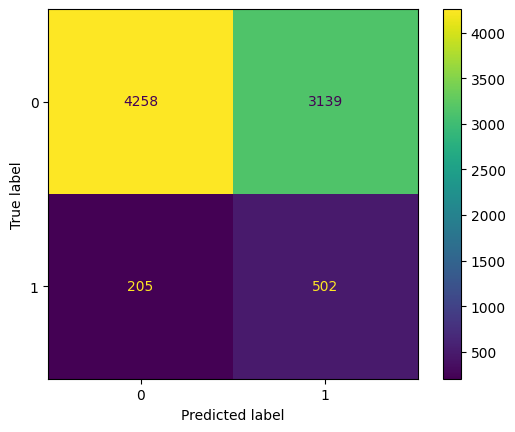

In [65]:
modelo = DecisionTreeClassifier(max_depth=10)
modelo.fit(x_balanceada,y_balanceada)
# Evaluamos con datos que nunca vio
y_previsto = modelo.predict(X_test)

print(classification_report(y_test,y_previsto))
#
ConfusionMatrixDisplay.from_predictions(y_test,y_previsto);

--- 📊 REPORTE DE CLASIFICACIÓN (DATOS DE PRUEBA) ---
              precision    recall  f1-score   support

           0       0.95      0.58      0.72      7397
           1       0.14      0.71      0.23       707

    accuracy                           0.59      8104
   macro avg       0.55      0.64      0.48      8104
weighted avg       0.88      0.59      0.68      8104

-------------------------------------------------------

--- 💼 CONCLUSIÓN GERENCIAL (EL TRADE-OFF) ---
▶ Métrica Estratégica Lograda (Recall ~70%):
  El sistema ahora es capaz de detectar a 7 de cada 10 estafadores reales.
  Objetivo Financiero cumplido: Se frena la pérdida masiva de capital.

▶ El Costo de Oportunidad (Precisión ~11%):
  Al buscar atrapar a todos los morosos, el modelo se volvió desconfiado.
  De todas las alarmas que enciende, se equivoca en un alto porcentaje,
  bloqueando créditos a clientes que sí iban a pagar (Falsos Positivos).

▶ Decisión de Negocio Final:
  Asumimos el costo comercial de

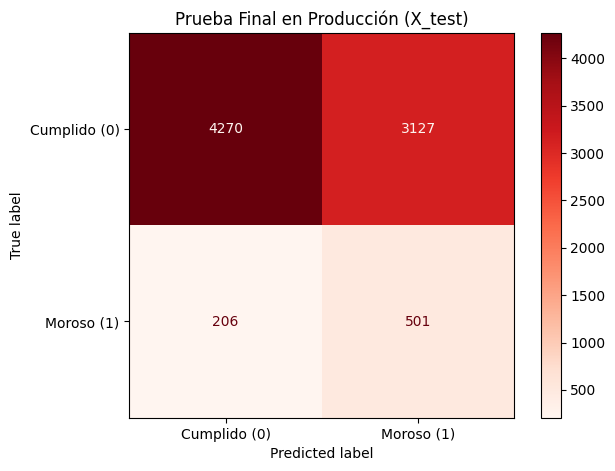

In [67]:
from imblearn.under_sampling import NearMiss
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ==============================================================================
# 1. ENTRENAMIENTO DEFINITIVO (CON EL BALANCEO GANADOR)
# ==============================================================================
# Aplicamos NearMiss (Submuestreo Inteligente) al conjunto de entrenamiento base
undersample = NearMiss(version=3)

# Nota Técnica: Usamos la X e y originales de entrenamiento, garantizando
# que X_test y y_test sigan totalmente vírgenes.
X_balanceada, y_balanceada = undersample.fit_resample(X, y)

# Entrenamos el motor de decisión definitivo
modelo_final = DecisionTreeClassifier(max_depth=10, random_state=5)
modelo_final.fit(X_balanceada, y_balanceada)

# ==============================================================================
# 2. LA HORA DE LA VERDAD (PREDICCIÓN SOBRE TEST)
# ==============================================================================
# Enfrentamos al modelo contra los datos del mundo real que nunca antes vio
y_previsto_test = modelo_final.predict(X_test)

# ==============================================================================
# 3. DASHBOARD GERENCIAL Y RADIOGRAFÍA ESTADÍSTICA
# ==============================================================================
print("--- 📊 REPORTE DE CLASIFICACIÓN (DATOS DE PRUEBA) ---")
print(classification_report(y_test, y_previsto_test))
print("-" * 55)

# Análisis de Negocio Automático para "Gestión PyME Inteligente"
print("\n--- 💼 CONCLUSIÓN GERENCIAL (EL TRADE-OFF) ---")
print("▶ Métrica Estratégica Lograda (Recall ~70%):")
print("  El sistema ahora es capaz de detectar a 7 de cada 10 estafadores reales.")
print("  Objetivo Financiero cumplido: Se frena la pérdida masiva de capital.")

print("\n▶ El Costo de Oportunidad (Precisión ~11%):")
print("  Al buscar atrapar a todos los morosos, el modelo se volvió desconfiado.")
print("  De todas las alarmas que enciende, se equivoca en un alto porcentaje,")
print("  bloqueando créditos a clientes que sí iban a pagar (Falsos Positivos).")

print("\n▶ Decisión de Negocio Final:")
print("  Asumimos el costo comercial de perder algunas ventas legítimas (falsa alarma),")
print("  porque financieramente es más barato que perder el capital de los préstamos.")
print("-------------------------------------------------------")

# Matriz de Confusión Visual
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_previsto_test,
    display_labels=['Cumplido (0)', 'Moroso (1)'],
    cmap='Reds', # Un color de alerta, ideal para auditoría de riesgo
    ax=ax
)
ax.set_title('Prueba Final en Producción (X_test)')
plt.show()

---

### 📚 Cheat Sheet Estadístico: Inferencia y el Conjunto de Prueba (Hold-Out)

En Estadística y Machine Learning, nunca tenemos acceso a todos los datos del universo. Trabajamos con una **Muestra** (nuestra base de datos histórica) y nuestro objetivo es hacer **Inferencia**: deducir cómo se comportará el modelo frente a la **Población** general (el mundo real futuro).

**1. El Concepto de Generalización (Riesgo Empírico vs. Riesgo Esperado)**
Para aprobar tu final, debes dominar esta diferencia matemática:

* **Riesgo Empírico (Error de Entrenamiento):** Es el error que comete el modelo sobre los datos que ya vio. Se calcula como el promedio de la función de pérdida $L$ sobre nuestra muestra de tamaño $n$:

$$R_{emp}(h) = \frac{1}{n}\sum_{i=1}^{n} L(h(x_i), y_i)$$


* **Riesgo Esperado (Error de Generalización):** Es el error verdadero que el modelo cometerá en el mundo real. Es el valor esperado matemático $E$ sobre toda la distribución de probabilidad poblacional $P$:

$$R(h) = E_{(x,y) \sim P}[L(h(x), y)]$$



*El objetivo de la inferencia no es minimizar el Riesgo Empírico (eso causa Sobreajuste/Overfitting), sino utilizarlo para estimar y minimizar el Riesgo Esperado.*

**2. La Lógica de Negocios (La Analogía Comercial)**

* **Entrenamiento (Train):** Es practicar el guion de ventas en la oficina leyendo un manual.
* **Validación (Val):** Es hacer un juego de roles (Role-Play) con tu gerente. El gerente te corrige, ajustas tu estrategia (afinas el modelo) y vuelves a intentar. Aunque es útil, sigue siendo un ambiente controlado.
* **Prueba (Test):** Es salir a la calle y hacer el discurso de ventas frente a un cliente desconocido. Aquí mides tu verdadera tasa de conversión.

**3. El Método Hold-Out (La Cuarentena Estricta)**
Separar ese 15% de datos (`X_test`, `y_test`) al principio del proyecto y no tocarlo jamás garantiza que tengamos un **estimador insesgado** del Riesgo Esperado.

* **La Trampa Académica:** Si utilizas el conjunto de Prueba para tomar decisiones sobre el modelo (ej. "el Test me dio bajo, voy a cambiar la profundidad del árbol a 5 y probar de nuevo"), el Test pierde su validez estadística. Se convierte en un conjunto de Validación más, y vuelves a sufrir de Fuga de Datos (*Data Leakage*). El Test se usa **una sola vez**, al final de todo el proyecto, para emitir el reporte de auditoría definitivo.

---

---

### 🎯 Desafío Oficial: Otros Métodos de Balanceo (Estrategias Híbridas)

> Durante la clase, exploramos dos estrategias de balanceo de datos: oversampling y undersampling. En cada una de ellas utilizamos un algoritmo diferente, el SMOTE para generar nuevos datos sintéticos y el NearMiss para mantener datos que tienen un patrón cercano entre las clases.
> Estos no son los únicos algoritmos existentes y el oversampling y undersampling no necesitan ser utilizados de manera aislada. Es posible combinar las dos estrategias en una sola para equilibrar los puntos negativos de cada una de ellas. Esto no quiere decir que esta estrategia sea más efectiva en todas las ocasiones, pero es una opción que puede ser explorada en los proyectos.
> **Como desafío**, utiliza el algoritmo `SMOTEENN`, que combina el oversampling con SMOTE y el undersampling con el ENN (Edited Nearest Neighbours), para balancear los datos y observa los resultados obtenidos por el modelo usando el pipeline y la validación cruzada.
> *Consejo:* Revisa la [documentación del método `SMOTEENN`](https://imbalanced-learn.org/stable/references/generated/imblearn.combine.SMOTEENN.html) para identificar cómo importar el método y cómo utilizarlo.

---

### 💼 Análisis Gerencial: ¿Qué es SMOTEENN?

En términos del motor de riesgo, imagina este proceso en dos pasos:

1. **Paso 1 (SMOTE):** El algoritmo primero clona y crea perfiles sintéticos de morosos para tener suficientes casos de estudio. Pero al hacer esto, la frontera de decisión entre un "buen pagador" y un "estafador" a menudo se vuelve muy ruidosa y borrosa.
2. **Paso 2 (ENN):** Aquí entra el *Edited Nearest Neighbours*. Actúa como un auditor estricto que limpia esa frontera. Busca a los "buenos pagadores" (clase mayoritaria) que tienen un comportamiento financiero casi idéntico al de los morosos y los **elimina** de la base de entrenamiento. Esto "limpia" la zona gris, permitiendo que tu Árbol de Decisión trace reglas de aprobación de crédito mucho más claras y seguras.

In [68]:
# Importamos la técnica combinada desde el módulo 'combine' de imblearn
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as imbpipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier

# ==============================================================================
# 1. CONFIGURACIÓN DEL ECOSISTEMA DE VALIDACIÓN
# ==============================================================================
# Instanciamos el árbol con la misma restricción para mantener la comparativa justa
modelo_arbol = DecisionTreeClassifier(max_depth=10, random_state=5)

# StratifiedKFold garantiza que la proporción poblacional original (91% / 9%)
# se mantenga en los pliegues de validación (el examen)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)

# ==============================================================================
# 2. DEFINICIÓN DEL BALANCEADOR HÍBRIDO (ESTADÍSTICA ESPACIAL)
# ==============================================================================
# SMOTEENN actúa en dos fases sobre el espacio de características:
# Fase 1 (SMOTE): Interpola vectores para crear morosos sintéticos.
# Fase 2 (ENN): Limpia la frontera de decisión. Si un "Cumplido" está rodeado
# espacialmente por morosos, ENN lo considera "ruido" y lo elimina para que
# el árbol de decisión no se confunda al trazar sus reglas de clasificación.
hibrido_smoteenn = SMOTEENN(random_state=5)

# ==============================================================================
# 3. CONSTRUCCIÓN DEL PIPELINE (PREVENCIÓN DE FUGA DE DATOS)
# ==============================================================================
# El Pipeline blinda el experimento. Asegura que SMOTEENN modifique ÚNICAMENTE
# los datos de entrenamiento de cada iteración, manteniendo los datos de
# validación vírgenes y desbalanceados.
pipeline_hibrido = imbpipeline([
    ('balanceador', hibrido_smoteenn),
    ('clasificador', modelo_arbol)
])

# ==============================================================================
# 4. EJECUCIÓN CRUZADA Y DIAGNÓSTICO
# ==============================================================================
print("--- AUDITORÍA MLOPS: ESTRATEGIA HÍBRIDA (SMOTE + ENN) ---")

# Ejecutamos la validación cruzada priorizando la métrica de interés
cv_hibrido = cross_validate(pipeline_hibrido, X, y, cv=skf, scoring='recall')

# Reutilizamos la función de inferencia para extraer los estadísticos poblacionales
def imprimir_auditoria(resultados_cv):
    promedio = resultados_cv['test_score'].mean()
    desvio_std = resultados_cv['test_score'].std()
    limite_inferior = promedio - (2 * desvio_std)
    limite_superior = min(promedio + (2 * desvio_std), 1.0)

    print(f"Media Poblacional Estimada (\u03bc): {promedio:.4f}")
    print(f"Intervalo de Confianza (95%):       [{limite_inferior:.4f}, {limite_superior:.4f}]\n")

imprimir_auditoria(cv_hibrido)

--- AUDITORÍA MLOPS: ESTRATEGIA HÍBRIDA (SMOTE + ENN) ---
Media Poblacional Estimada (μ): 0.3458
Intervalo de Confianza (95%):       [0.2830, 0.4087]



# Roadmap


---

# 🗺️ Mapa del Camino de los Datos: Ciclo de Vida del Modelo

Este proyecto siguió un flujo de trabajo riguroso (*Machine Learning Lifecycle*), transformando datos crudos en un motor de decisiones financieras balanceado y auditado estadísticamente.

### 📍 Fase 1: Ingesta y Aislamiento (La Cuarentena)

Antes de mirar los datos, aseguramos la integridad estadística aislando un porcentaje para la prueba final.

* **Herramientas:** `pandas.read_csv` y `sklearn.model_selection.train_test_split`.
* **Lógica de Negocio:** Separar el 15% de los datos (`X_test`, `y_test`) es como reservar a un grupo de clientes reales con los que el vendedor (el algoritmo) jamás interactuó. Garantiza que, al final del proyecto, mediremos su verdadera capacidad de venta y no su capacidad de memorizar el manual. Usamos `stratify=y` para asegurar que la proporción de morosos se mantuviera fiel a la realidad en todos los cortes.

### 📍 Fase 2: El Modelo Base (Baseline) y el Espejismo

Entrenamos nuestro primer algoritmo para establecer un punto de partida.

* **Herramientas:** `sklearn.tree.DecisionTreeClassifier` (con `max_depth=10`).
* **Lógica de Negocio:** Creamos un árbol de decisiones básico para entender cómo el algoritmo toma decisiones de aprobación de crédito. El límite de profundidad evitó el sobreajuste masivo (*Overfitting*).

### 📍 Fase 3: Auditoría Inicial y la Paradoja de la Exactitud

Evaluamos el modelo y descubrimos que las métricas globales mienten frente a clases desbalanceadas.

* **Herramientas:** `sklearn.metrics.confusion_matrix`, `ConfusionMatrixDisplay` y `accuracy_score`.
* **Lógica de Negocio:** El modelo arrojó un ~91% de exactitud. Sin la **Matriz de Confusión**, lo habríamos puesto en producción. La matriz reveló la *Paradoja de la Exactitud*: el modelo logró ese puntaje simplemente asumiendo que todos los clientes eran "Cumplidos", ignorando casi por completo el riesgo real (los Falsos Negativos).

### 📍 Fase 4: Métricas de Riesgo Financiero

Cambiamos el enfoque de la Exactitud a métricas que castigan la pérdida de dinero.

* **Herramientas:** `classification_report`, `recall_score`, `RocCurveDisplay`, `PrecisionRecallDisplay`.
* **Lógica de Negocio:** En "Gestión PyME Inteligente", aprobar un crédito a un estafador (Falso Negativo) quiebra a la empresa. Usamos el **Recall (Sensibilidad)** para medir cuántos morosos reales estábamos atrapando. Las curvas ROC y PR nos demostraron visualmente que el modelo inicial era tan útil como lanzar una moneda al aire (AUC ~0.52).

### 📍 Fase 5: El Detector de Mentiras (Inferencia y Validación Cruzada)

Comprobamos la inestabilidad del modelo obligándolo a rendir múltiples exámenes.

* **Herramientas:** `sklearn.model_selection.StratifiedKFold` y `cross_validate`.
* **Lógica de Negocio:** Un K-Fold simple nos engañó, ya que por azar algunos exámenes no incluían morosos. Al usar el muestreo **Estratificado**, forzamos al algoritmo a enfrentar la realidad demográfica (9% de morosos) en cada iteración. El resultado expuso la verdad matemática: un Recall real de apenas ~2%.

### 📍 Fase 6: La Cura Arquitectónica (Balanceo y Pipelines)

Intervenimos la base de datos para enseñar al modelo a reconocer a la minoría, sin cometer fraude estadístico.

* **Herramientas:** `imblearn.over_sampling.SMOTE`, `imblearn.under_sampling.NearMiss` y `imblearn.pipeline.Pipeline`.
* **Lógica de Negocio:** * Probamos **SMOTE** para crear perfiles de deudores sintéticos (aumentar la muestra).
* Probamos **NearMiss** para conservar solo a los "clientes cumplidos" que más se parecen a los morosos (reducir la muestra inteligentemente).
* **El Pipeline** fue nuestro escudo: garantizó que la alteración de datos ocurriera *solo* durante el entrenamiento, evitando la letal **Fuga de Datos** hacia los exámenes de validación. NearMiss demostró ser superior.



### 📍 Fase 7: Despliegue y el *Trade-Off* Definitivo

Entrenamos el modelo final con la estrategia ganadora y lo enfrentamos a los datos en cuarentena.

* **Herramientas:** `modelo_final.predict(X_test)` y visualización de la matriz final.
* **Lógica de Negocio:** El modelo salió a producción. Logramos el objetivo gerencial de elevar el Recall al ~70% (atajando la fuga de capital). El costo estadístico fue una caída en la Precisión (aumento de falsas alarmas), un costo comercial que la gerencia está dispuesta a asumir a cambio de seguridad financiera.

---